# Experiment — Cross-validated model selection

**Category:** model | **Task 11**

Take the strongest candidates from the baseline pass into a proper 5-fold cross-validation, pick the winner, refit on all data and persist it to `best_model/`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
import numpy as np
import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
import joblib
from sklearn.model_selection import train_test_split
from src.data_loading import PROCESSED_DIR, REPO_ROOT, TARGET
from src.features import build_features, split_xy
from src.modeling import candidate_models
from src.evaluation import cross_validate_rmse, regression_metrics, scoreboard
df = pd.read_csv(PROCESSED_DIR / 'grid_load_clean.csv')
X, y = split_xy(build_features(df))
print('X:', X.shape)

X: (1489, 21)


## Task 11 — 5-fold cross-validation on all candidates

In [2]:
cv_res = {}
for name, model in candidate_models().items():
    cv = cross_validate_rmse(model, X, y, n_splits=5)
    cv_res[name] = {'cv_mean_rmse': cv['mean_rmse'], 'cv_std_rmse': cv['std_rmse']}
cv_board = pd.DataFrame(cv_res).T.sort_values('cv_mean_rmse').round(3)
cv_board

/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


,cv_mean_rmse,cv_std_rmse
GradientBoosting,12.729,0.512
LinearRegression,12.752,0.429
Ridge,12.758,0.440
RandomForest,18.647,0.519
DecisionTree,27.425,1.621
Baseline (mean),102.346,3.751


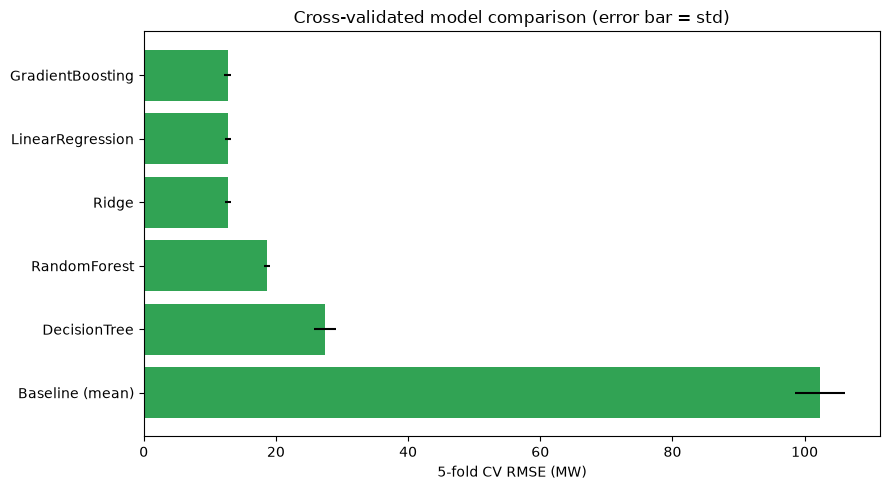

In [3]:
import matplotlib.pyplot as plt
from src.data_loading import FIGURES_DIR
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cv_board.index, cv_board['cv_mean_rmse'], xerr=cv_board['cv_std_rmse'],
        color='#31a354')
ax.invert_yaxis(); ax.set_xlabel('5-fold CV RMSE (MW)')
ax.set_title('Cross-validated model comparison (error bar = std)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'cv_model_comparison.png', dpi=120)
plt.show()

## Select best model, evaluate on held-out test, persist

In [4]:
best_name = cv_board.index[0]
best_model = candidate_models()[best_name]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(Xtr, ytr)
test_metrics = regression_metrics(yte, best_model.predict(Xte))
print('Best model:', best_name)
print('Held-out test metrics:', {k: round(v,3) for k,v in test_metrics.items()})

Best model: GradientBoosting
Held-out test metrics: {'RMSE': 12.857, 'MAE': 10.228, 'R2': 0.984, 'MAPE': 1.706}


In [5]:
# Refit on ALL data and save
best_model.fit(X, y)
out = REPO_ROOT / 'best_model'
out.mkdir(exist_ok=True)
joblib.dump(best_model, out / 'best_model.joblib')
pd.Series({'model': best_name, **test_metrics}).to_csv(out / 'metrics.csv')
pd.Series(X.columns, name='feature').to_csv(out / 'feature_names.csv', index=False)
print('Saved model + metrics to', out.relative_to(REPO))

Saved model + metrics to best_model


## Actual vs predicted (test window)

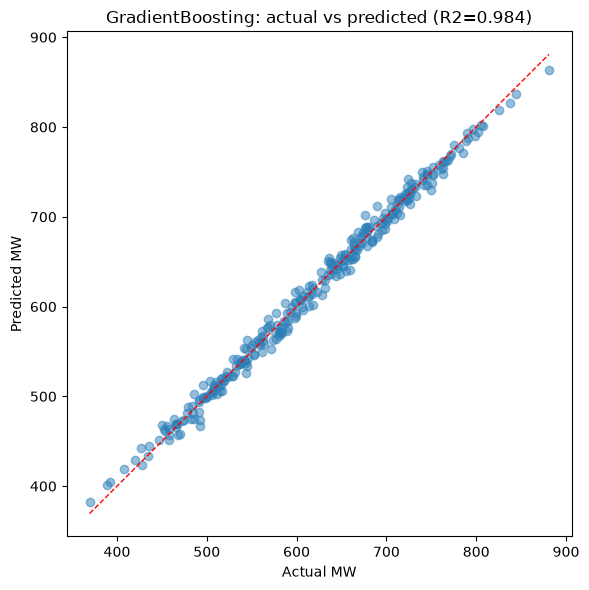

In [6]:
preds = best_model.predict(Xte)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yte, preds, alpha=0.5, color='#2c7fb8')
lims = [min(yte.min(), preds.min()), max(yte.max(), preds.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('Actual MW'); ax.set_ylabel('Predicted MW')
ax.set_title(f'{best_name}: actual vs predicted (R2={test_metrics["R2"]:.3f})')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'actual_vs_predicted.png', dpi=120)
plt.show()